In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from src.features import AC_POWER_FEATURES, make_ac_power_features
from src.models import (
    create_neural_network,
    create_hist_gradient_boosting_regressor,
    create_linear_regression,
    create_random_forest_regressor,
    create_xgboost_regressor,
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

we will use for first aproximation Linear Regression + Random Forest Regression and analyze the performance of the model using metrics as R^2, MSE and MAE

In [3]:
df = pd.read_parquet('../data/processed/solar_clean.parquet')

In [4]:
df.head()

,timestamp,irradiance,dc_power,ac_power,ambient_temp,module_temp_mean,date,plant_status,temp_difference,hour,day_of_year,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
20411,2019-03-31 00:01:00,56.507,34.868,23.639,2.4424,8.090500,2019-03-31,normal,5.648100,0,90,0.0,1.0,0.999769,0.021516
20412,2019-03-31 00:02:00,54.712,32.398,22.420,2.3776,8.018467,2019-03-31,normal,5.640867,0,90,0.0,1.0,0.999769,0.021516
20413,2019-03-31 00:03:00,53.359,32.380,20.447,2.3673,7.978900,2019-03-31,normal,5.611600,0,90,0.0,1.0,0.999769,0.021516
20414,2019-03-31 00:04:00,51.619,30.276,19.317,2.3898,7.901867,2019-03-31,normal,5.512067,0,90,0.0,1.0,0.999769,0.021516
20415,2019-03-31 00:05:00,51.039,27.784,18.397,2.4056,7.801533,2019-03-31,normal,5.395933,0,90,0.0,1.0,0.999769,0.021516


now we will separate complete dataset in three different sets:
- Training set: from first date to beginning of 2021
- Validation set: from first record of 2021 to beginning of 2022
- Test set: from first record of 2022 to beginning of 2023

Then we will see the performance of the model with unseen data for the first 2 month of 2023 (the data we have for 2023) and then we will try to predict the next months untill finishing 2023

In [5]:
# Train: 2019-2020
df_train = df[df['timestamp'] < '2021-01-01']

# Validation: 2021
df_val = df[
    (df['timestamp'] >= '2021-01-01') &
    (df['timestamp'] < '2022-01-01')
]

# Test: 2022
df_test = df[
    (df['timestamp'] >= '2022-01-01') &
    (df['timestamp'] < '2023-01-01')
]

now let's select the features and weights

In [6]:
training_features = list(AC_POWER_FEATURES)

weights = {
    'normal': 1.0,
    'unexplained_anomaly': 0.5,
    'shutdown_candidate': 1.0
}

sample_weight = df_train['plant_status'].map(weights)

in this case, we are assuming that irradiance, ambient temp and module temp are forecasted, for example: irradiance seeing the weather forecast based on how clear the sky is going to be, ambient temperature in the same way and module temperature in a mix of ambient temperature and heat absorbed by solar beams (irradiance)

split training set, validation set and test set into features and target variables

In [7]:
x_train = make_ac_power_features(df_train)
y_train = df_train['ac_power']

x_val = make_ac_power_features(df_val)
y_val = df_val['ac_power']

x_test = make_ac_power_features(df_test)
y_test = df_test['ac_power']

let's start training our first model, LinearRegression(), we are not going to apply weights because, as you will see, no weights has a better result

In [8]:
lr_model = create_linear_regression()

lr_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.71, -2.74, 4.17,...,-12.11, 6.98, 22.3 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['irradiance','ambient_temp','module_temp_mean',...,'hour_cos', 'day_of_year_sin','day_of_year_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-20.69
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


once our model fit training set, we will predict on validation set

In [9]:
y_val_pred = lr_model.predict(x_val)

see the different scores to know how well performanced the model

In [10]:
r2 = r2_score(y_val, y_val_pred)

mae = mean_absolute_error(y_val, y_val_pred)

rmse = mean_squared_error(y_val, y_val_pred) ** 0.5

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R²: 0.9802
MAE: 19.61
RMSE: 40.43


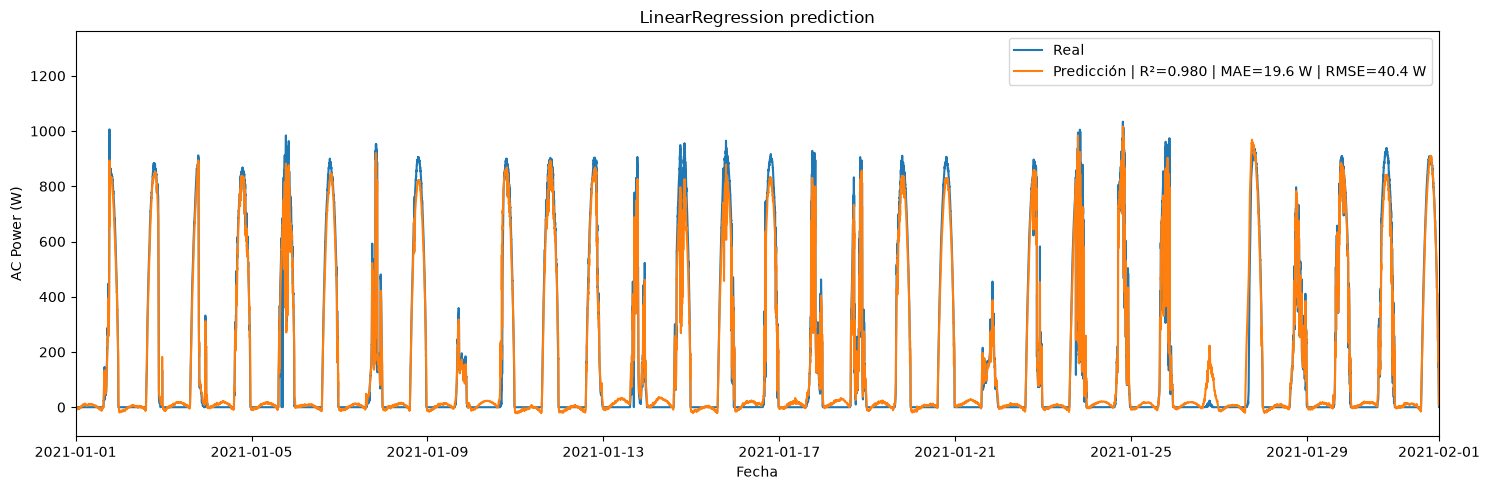

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_val['timestamp'],
    y_val,
    label='Real'
)

plt.plot(
    df_val['timestamp'],
    y_val_pred,
    label=f'Predicción | R²={r2:.3f} | MAE={mae:.1f} W | RMSE={rmse:.1f} W'
)

plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-02-01')) # type: ignore

plt.title('LinearRegression prediction')
plt.xlabel('Fecha')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

analyzing different weights

In [12]:
candidate_weights = [0.0, 0.25, 0.5, 0.75, 1.0]

In [13]:
results = []

for w in candidate_weights:

    weights = {
        'normal': 1.0,
        'unexplained_anomaly': w,
        'shutdown_candidate': 1.0
    }

    sample_weight = df_train['plant_status'].map(weights)

    model = LinearRegression()
    model.fit(x_train, y_train, sample_weight=sample_weight)

    y_val_pred = model.predict(x_val)

    results.append({
        'anomaly_weight': w,
        'R²': r2_score(y_val, y_val_pred),
        'MAE': mean_absolute_error(y_val, y_val_pred),
        'RMSE': mean_squared_error(y_val, y_val_pred) ** 0.5
    })

results_df = pd.DataFrame(results)
results_df

,anomaly_weight,R²,MAE,RMSE
0,0.00,0.980956,18.055025,39.690909
1,0.25,0.980847,18.402703,39.803836
2,0.50,0.980689,18.783077,39.968352
3,0.75,0.980486,19.187984,40.178168
4,1.00,0.980243,19.611647,40.427550


we can see in fact, no weights have a better performance

trying with Random Forest Regression for n number of trees

In [14]:
results_rf = []

for n in [30, 75, 100, 150]:
    rf_model = RandomForestRegressor(
        n_estimators=n,
        n_jobs=-1,
        random_state=42
    )

    rf_model.fit(x_train, y_train)
    y_val_pred_rf = rf_model.predict(x_val)

    results_rf.append({
            'Number of trees': n,
            'R²': r2_score(y_val, y_val_pred_rf),
            'MAE': mean_absolute_error(y_val, y_val_pred_rf),
            'RMSE': mean_squared_error(y_val, y_val_pred_rf) ** 0.5
        })

results_rf_df = pd.DataFrame(results_rf)
results_rf_df

,Number of trees,R²,MAE,RMSE
0,30,0.984665,10.836938,35.616721
1,75,0.984739,10.766530,35.530307
2,100,0.984738,10.768811,35.531992
3,150,0.984774,10.756122,35.490382


see that 75 trees is enough for a good random forest model, more will be more expensive and slowly with a minimal improvement

In [15]:
rf_model = create_random_forest_regressor()

rf_model.fit(x_train, y_train)
y_val_pred_rf = rf_model.predict(x_val)

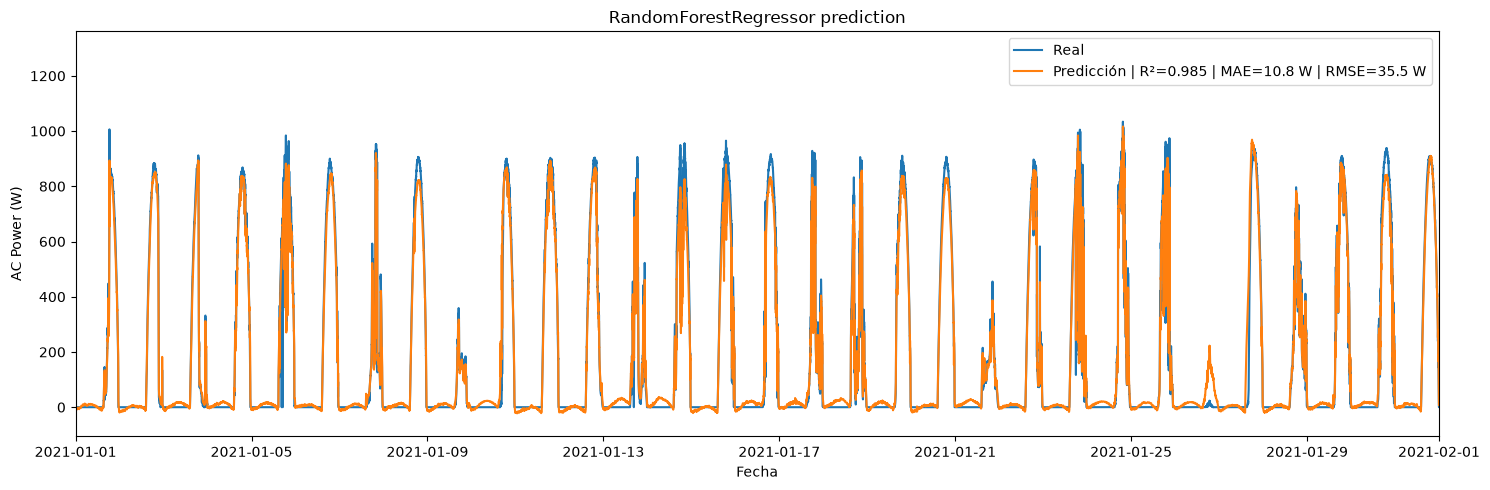

In [16]:
r2_rf = r2_score(y_val, y_val_pred_rf)

mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

rmse_rf = mean_squared_error(y_val, y_val_pred_rf) ** 0.5

plt.figure(figsize=(15,5))

plt.plot(
    df_val['timestamp'],
    y_val,
    label = 'Real'
)

plt.plot(
    df_val['timestamp'],
    y_val_pred,
    label=f'Predicción | R²={r2_rf:.3f} | MAE={mae_rf:.1f} W | RMSE={rmse_rf:.1f} W'
)

plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-02-01')) # type: ignore

plt.title('RandomForestRegressor prediction')
plt.xlabel('Fecha')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

random forest regression is even more accurate than linear regression

for night periods, both, linear and random forest regression models, can't follow properly the real data, that's probably the limitation for our model to predict more accurately

this problem is easy to solve using a physical restriction like:


In [17]:
y_val_pred[df_val['irradiance'] <= 0] = 0
y_val_pred_rf[df_val['irradiance'] <= 0] = 0

if you run again plotting cells, you will see the improvement, also in both, there is an improvement in their scores, but is a small change, probably because error in night periods are too small compared to the rest of the set

In [18]:
hgb_model = create_hist_gradient_boosting_regressor()
hgb_model.fit(x_train, y_train)

y_val_pred_hgb = hgb_model.predict(x_val)
y_val_pred_hgb[df_val['irradiance'] <= 0] = 0

r2_hgb = r2_score(y_val, y_val_pred_hgb)

mae_hgb = mean_absolute_error(y_val, y_val_pred_hgb)

rmse_hgb = mean_squared_error(y_val, y_val_pred_hgb) ** 0.5

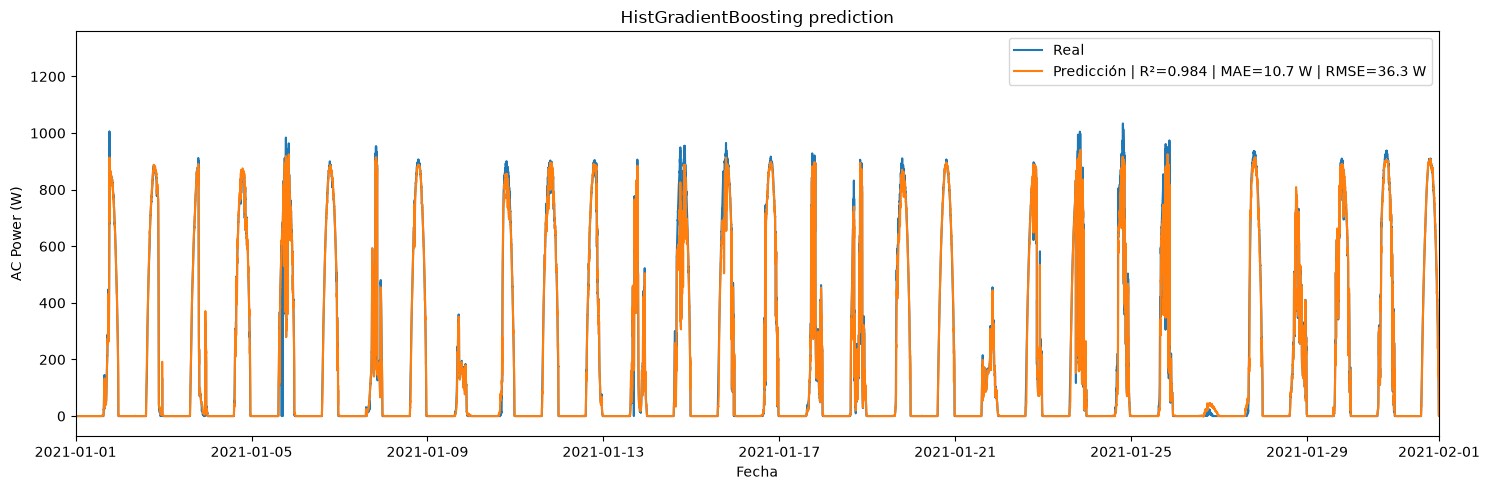

In [19]:
plt.figure(figsize=(15,5))

plt.plot(
    df_val['timestamp'],
    y_val,
    label = 'Real'
)

plt.plot(
    df_val['timestamp'],
    y_val_pred_hgb,
    label=f'Predicción | R²={r2_hgb:.3f} | MAE={mae_hgb:.1f} W | RMSE={rmse_hgb:.1f} W'
)

plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-02-01')) # type: ignore

plt.title('HistGradientBoosting prediction')
plt.xlabel('Fecha')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
xgb_model = create_xgboost_regressor()

xgb_model.fit(x_train, y_train)
y_val_pred_xgb = xgb_model.predict(x_val)
y_val_pred_xgb[df_val['irradiance'] <= 0] = 0

r2_xgb = r2_score(y_val, y_val_pred_xgb)

mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)

rmse_xgb = mean_squared_error(y_val, y_val_pred_xgb) ** 0.5

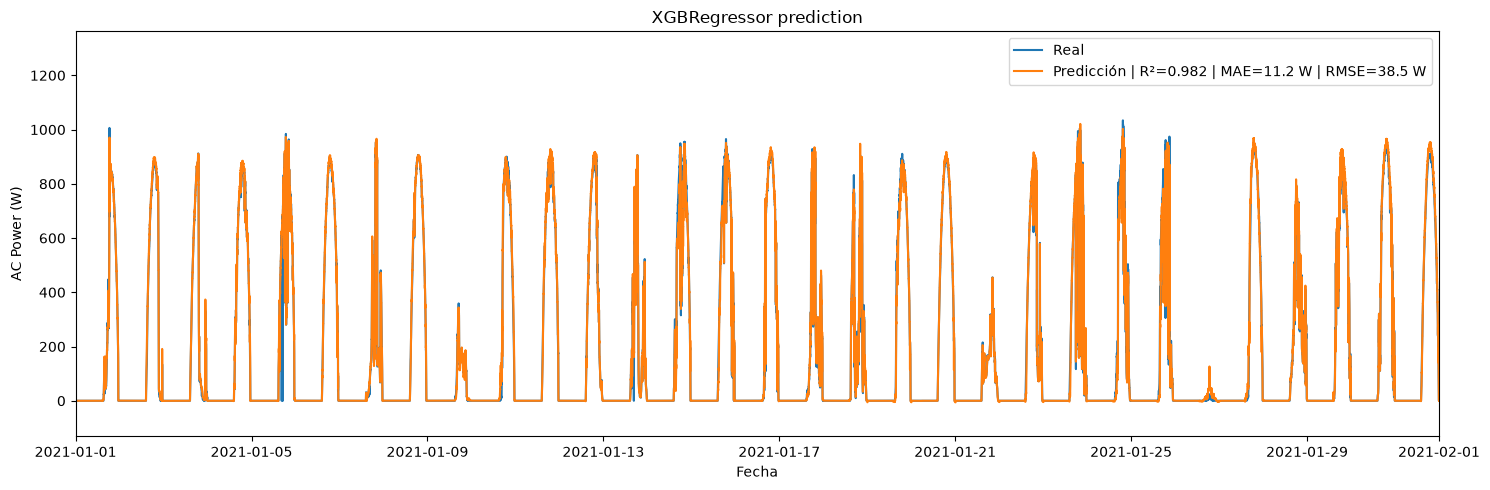

In [21]:
plt.figure(figsize=(15,5))

plt.plot(
    df_val['timestamp'],
    y_val,
    label = 'Real'
)

plt.plot(
    df_val['timestamp'],
    y_val_pred_xgb,
    label=f'Predicción | R²={r2_xgb:.3f} | MAE={mae_xgb:.1f} W | RMSE={rmse_xgb:.1f} W'
)

plt.xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-02-01')) # type: ignore

plt.title('XGBRegressor prediction')
plt.xlabel('Fecha')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
compar = pd.DataFrame({
    'Model': [
        'LinearRegression',
        'RandomForestRegressor',
        'HistGradientBoostingRegressor',
        'XGBRegressor'
    ],
    'R²': [r2, r2_rf, r2_hgb, r2_xgb],
    'MAE': [mae, mae_rf, mae_hgb, mae_xgb],
    'RMSE': [rmse, rmse_rf, rmse_hgb, rmse_xgb]
})

compar

,Model,R²,MAE,RMSE
0,LinearRegression,0.980243,19.611647,40.427550
1,RandomForestRegressor,0.984739,10.766530,35.530307
2,HistGradientBoostingRegressor,0.984092,10.679081,36.275562
3,XGBRegressor,0.982086,11.237207,38.495537


If we look at the scores, we can easily say that Random Forest is the best model, but also checking time it takes for the model to fit the data, random forest is the slowest with 16.5s, just behind is XGBregressor with 8.1s, then histgradientboostingregressor with 1.1s and linear regression with less than 0.2s

so, globally i could say that HisGradientBoostingRegressor method is better for big dataset with high capacity of prediction without being slowly and heavy

In [23]:
y_test_pred_lr = lr_model.predict(x_test)
y_test_pred_rf = rf_model.predict(x_test)
y_test_pred_hgb = hgb_model.predict(x_test)
y_test_pred_xgb = xgb_model.predict(x_test)

In [24]:
results_test = pd.DataFrame({
    'Model': [
        'LinearRegression',
        'RandomForestRegressor',
        'HistGradientBoostingRegressor',
        'XGBRegressor'
    ],
    'R²': [
        r2_score(y_test, y_test_pred_lr),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_hgb),
        r2_score(y_test, y_test_pred_xgb)
    ],
    'MAE (W)': [
        mean_absolute_error(y_test, y_test_pred_lr),
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_hgb),
        mean_absolute_error(y_test, y_test_pred_xgb)
    ],
    'RMSE (W)': [
        mean_squared_error(y_test, y_test_pred_lr) ** 0.5,
        mean_squared_error(y_test, y_test_pred_rf) ** 0.5,
        mean_squared_error(y_test, y_test_pred_hgb) ** 0.5,
        mean_squared_error(y_test, y_test_pred_xgb) ** 0.5
    ]
})

results_test

,Model,R²,MAE (W),RMSE (W)
0,LinearRegression,0.944764,27.784911,68.319925
1,RandomForestRegressor,0.969949,18.041422,50.392716
2,HistGradientBoostingRegressor,0.971081,18.301138,49.434491
3,XGBRegressor,0.967471,19.181870,52.429190


looking at the scores, it seems like the performance for 2022 is worse than for 2021, the big shutdown existing for 2022 maybe didn't let the models to fit more data, reducing the errors and explaining more variability, but is more probably that 2021 is more similar to 2019 and 2020 than 2022, the excelent results we got for 2021 is due to temperatures and irradiance that follows similar values of 2019 and 2020, that are the years inside the training set

let's check the performance by plotting predictions and real values

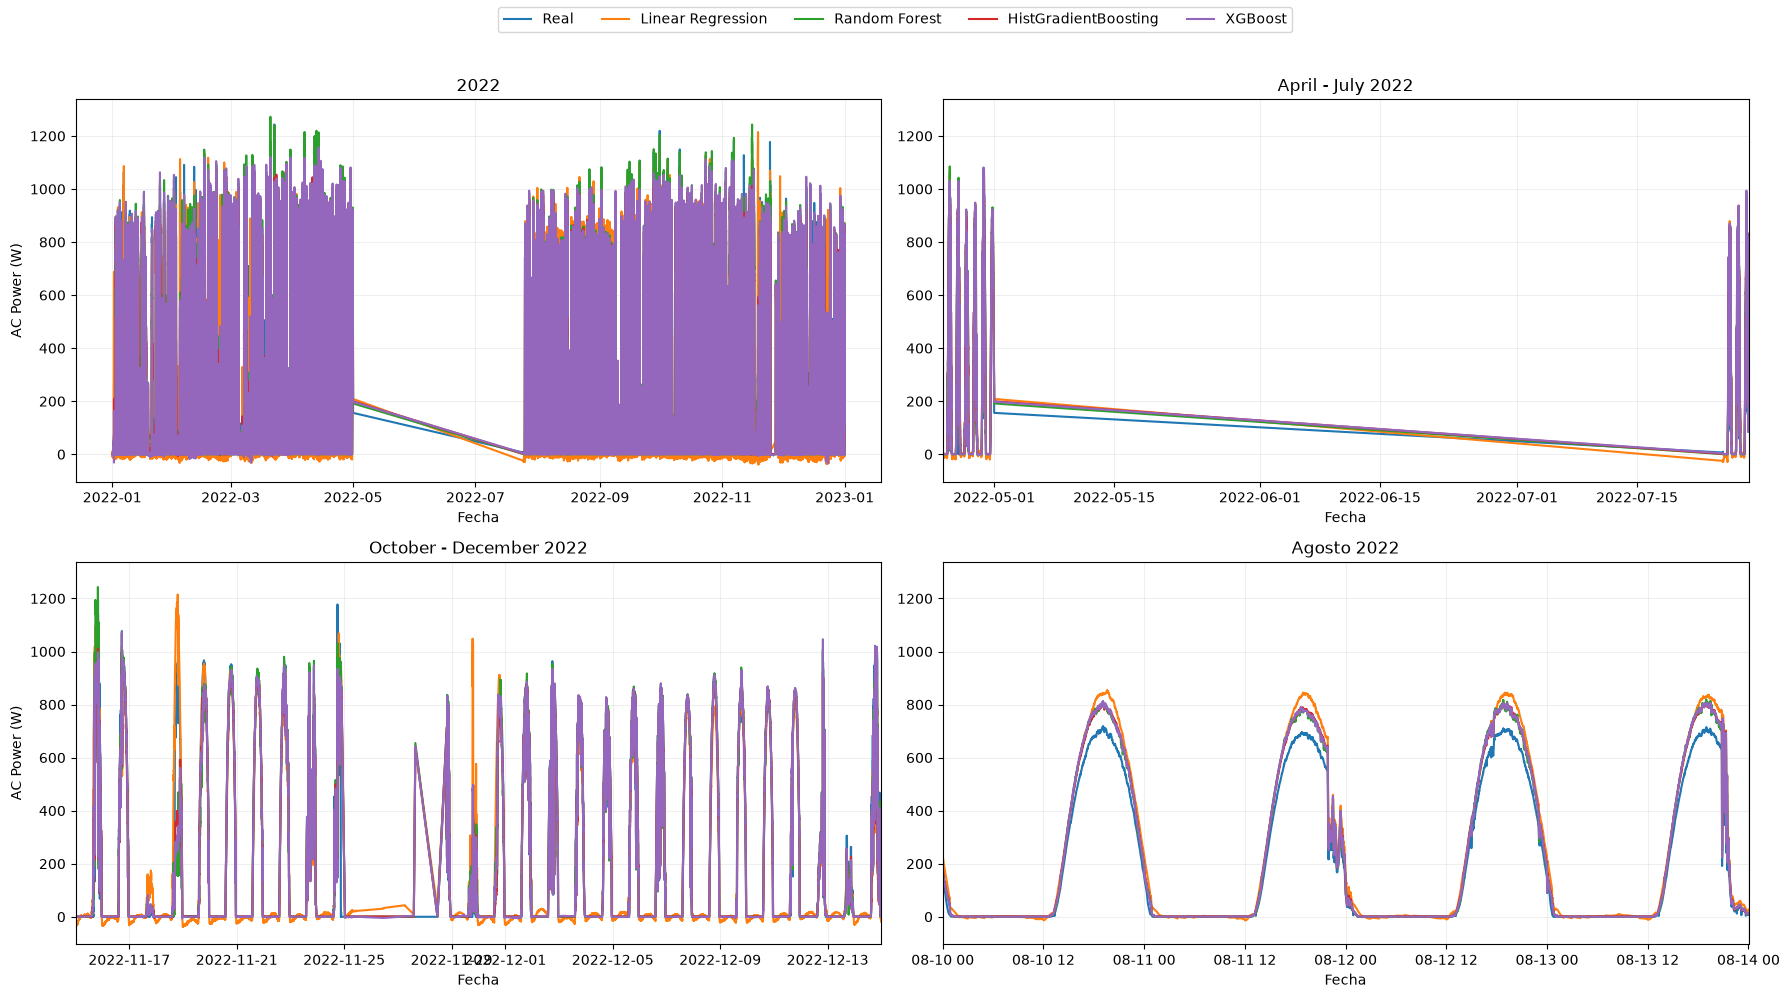

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

plot_df = pd.DataFrame({
    'timestamp': df_test['timestamp'].values,
    'Real': y_test.values,
    'Linear Regression': y_test_pred_lr,
    'Random Forest': y_test_pred_rf,
    'HistGradientBoosting': y_test_pred_hgb,
    'XGBoost': y_test_pred_xgb
})

# ---------------------------
# 1. Hole year
# ---------------------------
ax = axes[0, 0]

ax.plot(plot_df['timestamp'], plot_df['Real'], label='Real')
ax.plot(plot_df['timestamp'], plot_df['Linear Regression'], label='Linear Regression')
ax.plot(plot_df['timestamp'], plot_df['Random Forest'], label='Random Forest')
ax.plot(plot_df['timestamp'], plot_df['HistGradientBoosting'], label='HistGradientBoosting')
ax.plot(plot_df['timestamp'], plot_df['XGBoost'], label='XGBoost')

ax.set_title('2022')
ax.set_ylabel('AC Power (W)')

# ---------------------------
# 2. April - July
# ---------------------------
ax = axes[0, 1]

ax.plot(plot_df['timestamp'], plot_df['Real'])
ax.plot(plot_df['timestamp'], plot_df['Linear Regression'])
ax.plot(plot_df['timestamp'], plot_df['Random Forest'])
ax.plot(plot_df['timestamp'], plot_df['HistGradientBoosting'])
ax.plot(plot_df['timestamp'], plot_df['XGBoost'])

ax.set_xlim(pd.Timestamp('2022-04-25'), pd.Timestamp('2022-07-28'))
ax.set_title('April - July 2022')

# ---------------------------
# 3. October - December
# ---------------------------
ax = axes[1, 0]

ax.plot(plot_df['timestamp'], plot_df['Real'])
ax.plot(plot_df['timestamp'], plot_df['Linear Regression'])
ax.plot(plot_df['timestamp'], plot_df['Random Forest'])
ax.plot(plot_df['timestamp'], plot_df['HistGradientBoosting'])
ax.plot(plot_df['timestamp'], plot_df['XGBoost'])

ax.set_xlim(pd.Timestamp('2022-11-15'), pd.Timestamp('2022-12-15'))
ax.set_title('October - December 2022')
ax.set_ylabel('AC Power (W)')

# ---------------------------
# 4. August
# ---------------------------
ax = axes[1, 1]

ax.plot(plot_df['timestamp'], plot_df['Real'])
ax.plot(plot_df['timestamp'], plot_df['Linear Regression'])
ax.plot(plot_df['timestamp'], plot_df['Random Forest'])
ax.plot(plot_df['timestamp'], plot_df['HistGradientBoosting'])
ax.plot(plot_df['timestamp'], plot_df['XGBoost'])

ax.set_xlim(pd.Timestamp('2022-08-10'), pd.Timestamp('2022-08-14'))
ax.set_title('Agosto 2022')

# Etiquetas comunes
for ax in axes.flat:
    ax.set_xlabel('Fecha')
    ax.grid(alpha=0.2)

# Leyenda común
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5)

plt.tight_layout(rect=[0, 0, 1, 0.94]) # type: ignore
plt.show()

let's study why 2022 performance worse than 2021, we will check scores for each month of 2022

In [ ]:
monthly_results = df_test[['timestamp']].copy()

monthly_results['y_true'] = y_test.values
monthly_results['y_pred'] = y_test_pred_hgb

monthly_results['month'] = monthly_results['timestamp'].dt.month

monthly_metrics = monthly_results.groupby('month').apply(
    lambda x: pd.Series({
        'R²': r2_score(x['y_true'], x['y_pred']),
        'MAE': mean_absolute_error(x['y_true'], x['y_pred']),
        'RMSE': mean_squared_error(x['y_true'], x['y_pred']) ** 0.5
    })
)

monthly_metrics.sort_values(by='R²', ascending=True) # type: ignore

,R²,MAE,RMSE
month,,,
9,0.924485,24.938140,74.066467
2,0.954868,25.500955,64.133142
11,0.964894,15.455335,58.686481
3,0.967747,21.812348,51.743820
12,0.968070,13.798220,47.030494
8,0.977332,22.408880,38.578643
1,0.977529,16.236057,41.511280
7,0.982625,19.420797,32.782147
4,0.985571,19.301111,37.525036


seeing which month did the worst performance, now check if this is because of bad quality or quantity of data

In [27]:
monthly_counts = (
    df_test
    .groupby(df_test['timestamp'].dt.month)
    .size()
    .rename('n_samples')
)

monthly_metrics = monthly_metrics.sort_index()

monthly_metrics

,R²,MAE,RMSE
month,,,
1,0.977529,16.236057,41.511280
2,0.954868,25.500955,64.133142
3,0.967747,21.812348,51.743820
4,0.985571,19.301111,37.525036
7,0.982625,19.420797,32.782147
8,0.977332,22.408880,38.578643
9,0.924485,24.938140,74.066467
10,0.998863,5.524786,11.110035
11,0.964894,15.455335,58.686481


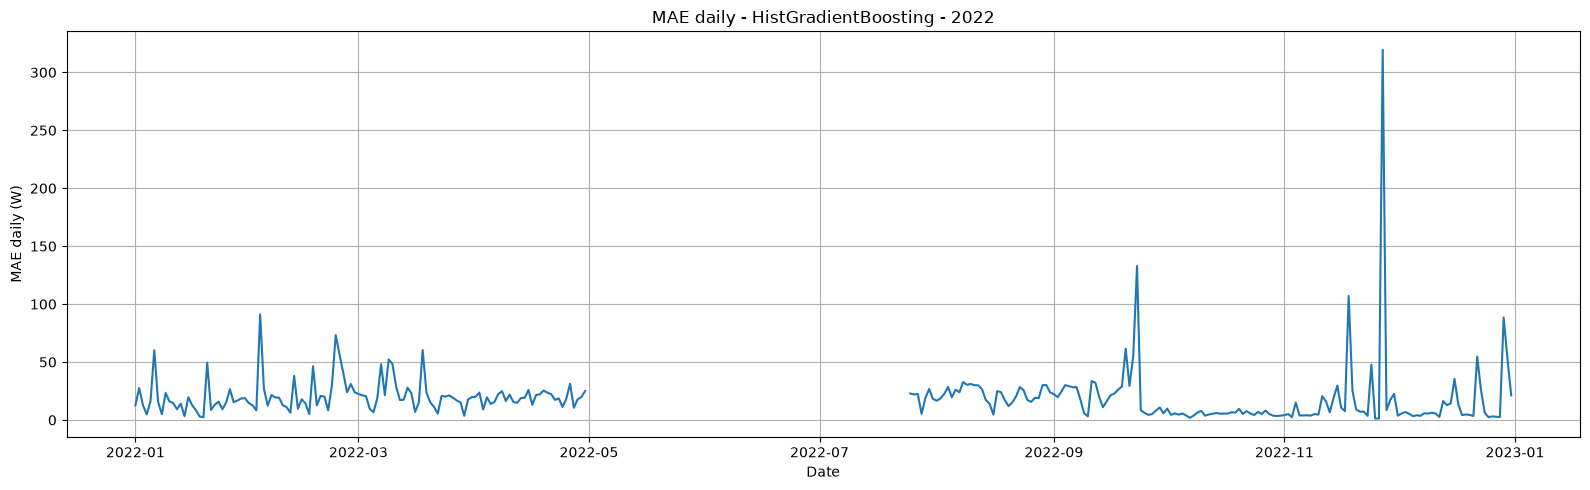

In [28]:
plot_errors = df_test[['timestamp']].copy()

plot_errors['absolute_error'] = np.abs(
    y_test.values - y_test_pred_hgb
)

daily_error = (
    plot_errors
    .set_index('timestamp')
    ['absolute_error']
    .resample('D')
    .mean()
)

plt.figure(figsize=(16, 5))

plt.plot(
    daily_error.index,
    daily_error.values
)

plt.xlabel('Date')
plt.ylabel('MAE daily (W)')
plt.title('MAE daily - HistGradientBoosting - 2022')
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
error_analysis = df_test[['timestamp', 'irradiance', 'ambient_temp',
                          'module_temp_mean', 'plant_status']].copy()

error_analysis['y_true'] = y_test.values
error_analysis['y_pred'] = y_test_pred_hgb

error_analysis['error'] = (
    error_analysis['y_true'] - error_analysis['y_pred']
)

error_analysis['absolute_error'] = (
    error_analysis['error'].abs()
)

error_analysis.sort_values(
    'absolute_error',
    ascending=False
).head(20)

,timestamp,irradiance,ambient_temp,module_temp_mean,plant_status,y_true,y_pred,error,absolute_error
1765731,2022-09-20 20:13:00,1247.7,30.545,54.971333,unexplained_anomaly,0.06633,973.233656,-973.167326,973.167326
1538081,2022-04-15 18:03:00,1165.0,13.799,43.910000,unexplained_anomaly,0.00000,968.953709,-968.953709,968.953709
1538080,2022-04-15 18:02:00,1167.0,14.099,43.873667,unexplained_anomaly,0.00000,968.589702,-968.589702,968.589702
1538082,2022-04-15 18:04:00,1160.0,13.433,44.135333,unexplained_anomaly,1.81630,967.427474,-965.611174,965.611174
1538078,2022-04-15 18:00:00,1146.7,14.613,42.535000,unexplained_anomaly,0.00000,951.826688,-951.826688,951.826688
1492108,2022-03-14 19:50:00,1138.4,10.668,44.134333,unexplained_anomaly,0.00000,951.063068,-951.063068,951.063068
1492109,2022-03-14 19:51:00,1136.8,10.488,45.228000,unexplained_anomaly,0.00000,949.796318,-949.796318,949.796318
1538079,2022-04-15 18:01:00,1155.9,14.197,43.442667,unexplained_anomaly,0.00000,949.008436,-949.008436,949.008436
1538077,2022-04-15 17:59:00,1151.3,14.795,42.016333,unexplained_anomaly,0.00000,948.589304,-948.589304,948.589304
1764177,2022-09-19 18:19:00,1209.1,29.512,65.041000,unexplained_anomaly,0.00000,948.243258,-948.243258,948.243258


it seems this rows hasn't been correctly classify, they should be shutdown_candidates not unexplained_anomaly, whatever this is a real situation that no one can predict and we didn't apply the weights in final models

now the bad performance is explained, but the only thing we can do is to drop this rows for the calculation of scores, so we are going to continue

to compare with one additional model, i will make a TensorFlow model and see how it performance 2022

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [31]:
nn_model = create_neural_network()

E0000 00:00:1790841516.713636    7619 cuda_executor.cc:1690] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:68

W0000 00:00:1790841516.714530    8388 cuda_executor.cc:1710] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:77
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:107
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:112

W0000 00:00:1790841516.731487    7619 dlopen_checker.cc:38] Could not load dynamic library 'libcudart.so.12'; dlerror: libcudart.so.12: cannot open shared object file: No such file or directory
W0000 00:00:1790841516.731503    761

In [32]:
history = nn_model.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=10,
    batch_size=1024,
    verbose=1
)

Epoch 1/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 43677.0234 - mae: 97.0504 - val_loss: 3359.5217 - val_mae: 35.2376
Epoch 2/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1891.9541 - mae: 23.6332 - val_loss: 1623.4347 - val_mae: 18.9451
Epoch 3/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1199.3552 - mae: 14.9669 - val_loss: 1393.4166 - val_mae: 15.3847
Epoch 4/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1005.8419 - mae: 12.5133 - val_loss: 1366.5020 - val_mae: 14.5708
Epoch 5/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 897.7821 - mae: 11.6154 - val_loss: 1339.6528 - val_mae: 14.1038
Epoch 6/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 802.8503 - mae: 11.2619 - val_loss: 1318.1506 - val_mae: 13.9362
Epoch 7/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 724.7917 - mae: 11.1020 - val_loss: 1300.7902 - val_mae: 13.7935
Epoch 8/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 663.9242 - mae: 10.8442 - val_loss: 1284.0609 - val_mae: 13.

In [33]:
y_val_pred_nn = nn_model.predict(x_val_scaled).flatten()

16376/16376 ━━━━━━━━━━━━━━━━━━━━ 8s 476us/step


In [34]:
r2_nn = r2_score(y_val, y_val_pred_nn)
mae_nn = mean_absolute_error(y_val, y_val_pred_nn)
rmse_nn = mean_squared_error(y_val, y_val_pred_nn) ** 0.5

print(f"R²: {r2_nn:.4f}")
print(f"MAE: {mae_nn:.2f} W")
print(f"RMSE: {rmse_nn:.2f} W")

R²: 0.9847
MAE: 13.58 W
RMSE: 35.53 W


these are good scores, but it seems that in validation set, HistGradientBoosting is better model for a few points

let's use test set to finally see how it does

In [35]:
y_test_pred_nn = nn_model.predict(x_test_scaled).flatten()

12430/12430 ━━━━━━━━━━━━━━━━━━━━ 6s 480us/step


In [36]:
results_test = pd.DataFrame({
    'Model': [
        'LinearRegression',
        'RandomForestRegressor',
        'HistGradientBoostingRegressor',
        'XGBRegressor',
        'nn_model'
    ],
    'R²': [
        r2_score(y_test, y_test_pred_lr),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_hgb),
        r2_score(y_test, y_test_pred_xgb),
        r2_score(y_test, y_test_pred_nn)
    ],
    'MAE (W)': [
        mean_absolute_error(y_test, y_test_pred_lr),
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_hgb),
        mean_absolute_error(y_test, y_test_pred_xgb),
        mean_absolute_error(y_test, y_test_pred_nn)
    ],
    'RMSE (W)': [
        mean_squared_error(y_test, y_test_pred_lr) ** 0.5,
        mean_squared_error(y_test, y_test_pred_rf) ** 0.5,
        mean_squared_error(y_test, y_test_pred_hgb) ** 0.5,
        mean_squared_error(y_test, y_test_pred_xgb) ** 0.5,
        mean_squared_error(y_test, y_test_pred_nn) ** 0.5
    ]
})

results_test

,Model,R²,MAE (W),RMSE (W)
0,LinearRegression,0.944764,27.784911,68.319925
1,RandomForestRegressor,0.969949,18.041422,50.392716
2,HistGradientBoostingRegressor,0.971081,18.301138,49.434491
3,XGBRegressor,0.967471,19.181870,52.429190
4,nn_model,0.974114,20.033040,46.770779


comparing R^2 score is easy to see that is the best model to explain variability, just over gradient boosting regressor, it has bigger MAE but lower RMSE, meaning that the new model has less big errors and more absolute error in general

in total both models does a great jobs predicting ac power in 2022, but gradient boosting has the plus that the trainning lasted 1.1s since for nn model lasted 10.5s

now, i will save each model in a new folder /models to use them in the next notebook

In [37]:
from pathlib import Path
import joblib

# to generate the folder
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)


# ==========================================
# 1. Linear Regression
# ==========================================

joblib.dump(
    lr_model,
    models_dir / "linear_regression.joblib"
)


# ==========================================
# 2. Random Forest Regressor
# ==========================================

joblib.dump(
    rf_model,
    models_dir / "random_forest_regressor.joblib"
)


# ==========================================
# 3. HistGradientBoostingRegressor
# ==========================================

joblib.dump(
    hgb_model,
    models_dir / "hist_gradient_boosting_regressor.joblib"
)


# ==========================================
# 4. XGBoost Regressor
# ==========================================

joblib.dump(
    xgb_model,
    models_dir / "xgboost_regressor.joblib"
)


# ==========================================
# 5. Neural Network - TensorFlow / Keras
# ==========================================

nn_model.save(
    models_dir / "neural_network.keras"
)


# ==========================================
# 6. Scaler
# ==========================================

joblib.dump(
    scaler,
    models_dir / "scaler.joblib"
)


print("Todos los modelos y el scaler se han guardado correctamente.")

Todos los modelos y el scaler se han guardado correctamente.
